In [1]:
# Importing all the essential Python libraries

import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set_style('whitegrid')

In [2]:
import yfinance as yf
from datetime import datetime

# Define the time period
end = datetime.now()
start= datetime(end.year-1,end.month,end.day)

# Fetch the APPLE data using yfinance
AAPL = yf.download("AAPL", start=start, end=end)

AAPL=pd.DataFrame(AAPL)


[*********************100%%**********************]  1 of 1 completed


In [5]:
AAPL.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-08-25,168.779999,170.139999,168.350006,170.029999,169.027267,51218200
2022-08-26,170.570007,171.050003,163.559998,163.619995,162.655060,78961000
2022-08-29,161.149994,162.899994,159.820007,161.380005,160.428284,73314000
2022-08-30,162.130005,162.559998,157.720001,158.910004,157.972855,77906200
2022-08-31,160.309998,160.580002,157.139999,157.220001,156.292816,87991100


In [3]:
# Some Basic info about the Apple Stock

AAPL.describe()

,Open,High,Low,Close,Adj Close,Volume
count,251.000000,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,159.552208,161.311410,157.926255,159.660677,159.156246,6.996628e+07
std,18.416747,18.162877,18.678619,18.387806,18.548214,2.390984e+07
min,126.010002,127.769997,124.169998,125.019997,124.488876,3.145820e+07
25%,145.815002,147.340004,144.014999,145.919998,145.274216,5.140870e+07
50%,154.789993,157.089996,153.369995,155.000000,154.394073,6.549670e+07
75%,173.735001,175.170006,172.845001,174.345001,174.245003,8.135480e+07
max,196.240005,198.229996,195.279999,196.449997,196.185074,1.647624e+08


<AxesSubplot:xlabel='Date'>

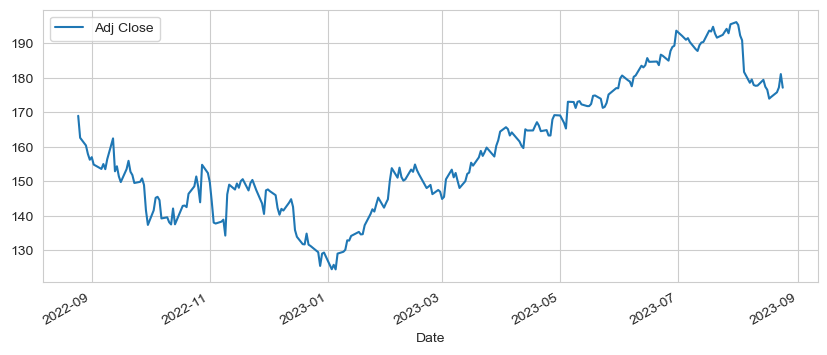

In [4]:
# Plotting Adjusted Closing price for Apple Stock

AAPL['Adj Close'].plot(legend=True,figsize=(10,4))

<AxesSubplot:xlabel='Date'>

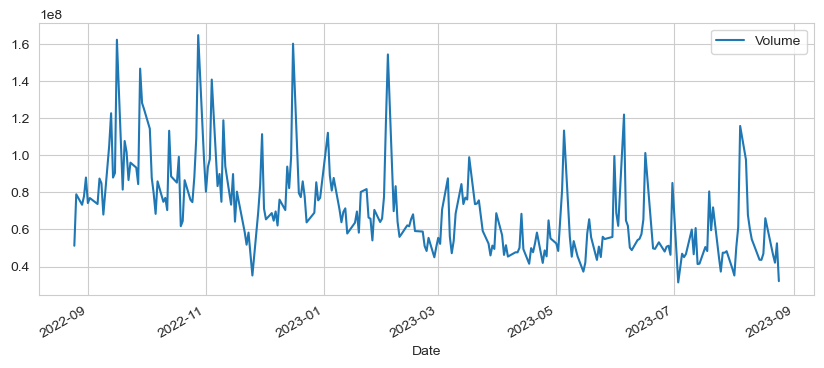

In [5]:
# Plotting the total volume of stock being traded each day

AAPL['Volume'].plot(legend=True,figsize=(10,4))

In [6]:
# Calculating Moving average for 10, 20 and 50 days of the stock price

ma_day = [10, 20, 50]

for ma in ma_day:
    column_name = "MA for %s days" % (str(ma))
    
    AAPL[column_name] = AAPL['Adj Close'].rolling(window=ma).mean()


<AxesSubplot:xlabel='Date'>

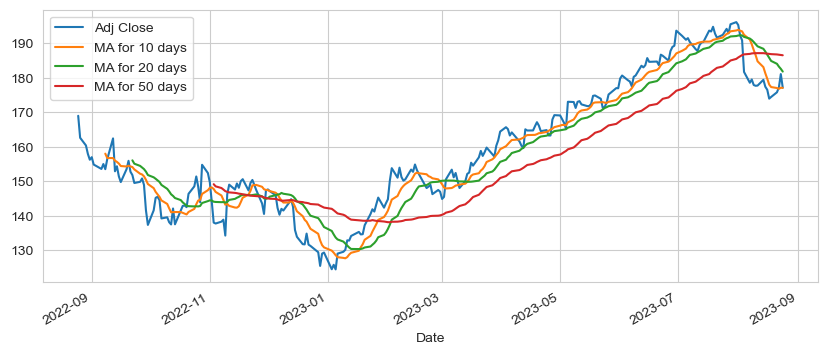

In [7]:
# Plotting the moving averages

AAPL[['Adj Close', 'MA for 10 days','MA for 20 days','MA for 50 days']].plot(subplots=False,figsize=(10,4))

<AxesSubplot:xlabel='Date'>

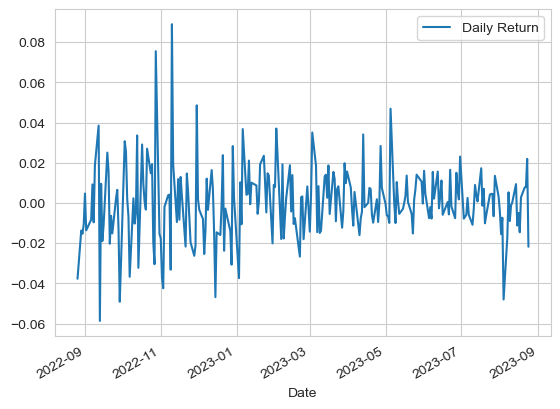

In [8]:
# Plotting Daily returns as a function of Percent change in Adjusted Close value

AAPL['Daily Return'] = AAPL['Adj Close'].pct_change()

AAPL['Daily Return'].plot(legend=True)

C:\Users\chott\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Daily Return', ylabel='Density'>

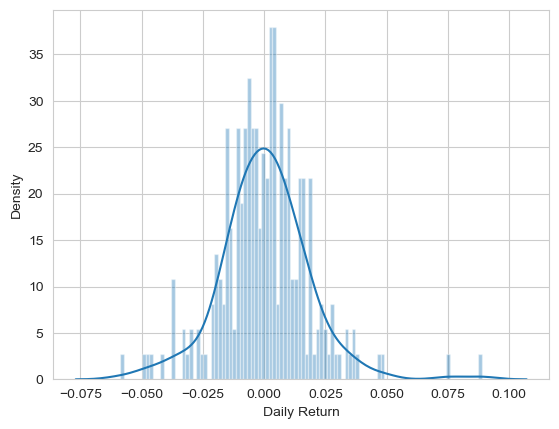

In [9]:
# Plotting the average daily returns of the stock

sns.distplot(AAPL['Daily Return'].dropna(),bins=100)

Text(0, 0.5, 'Risk')

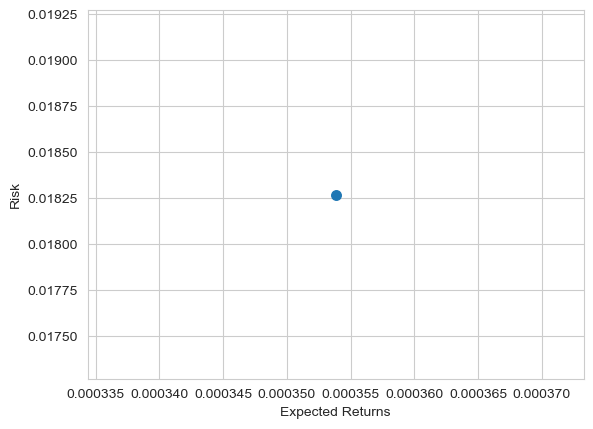

In [10]:
# Risk Analysis --  Comparing the Risk vs Expected returns

rets = AAPL['Daily Return'].dropna()

area = np.pi*15

plt.scatter(rets.mean(),rets.std(),s=area)

plt.xlabel('Expected Returns')
plt.ylabel('Risk')

C:\Users\chott\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Daily Return', ylabel='Density'>

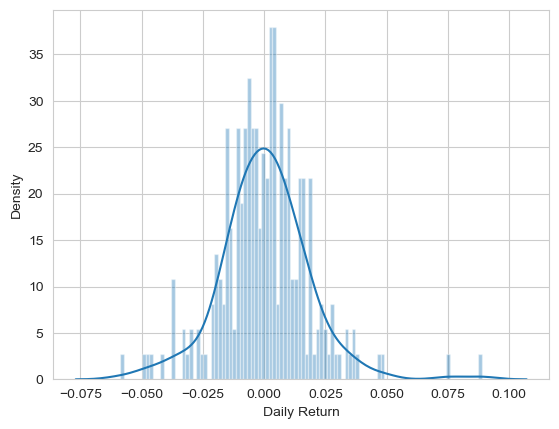

In [11]:
# Visualizing the Value at Risk

sns.distplot(AAPL['Daily Return'].dropna(),bins=100)

In [12]:
# Using Quantiles and the Bootstrap Method to calculate the numerical risk of the stock

AAPL['Daily Return'].quantile(0.05)

-0.03027362713109296

In [13]:
## Monte Carlo Simulation

days = 365

dt = 1/days

mu = rets.mean()

sigma = rets.std()

In [14]:
# Defining the Monte Carlo Simulation Function

def stock_monte_carlo(start_price,days,mu,sigma):
    
    price = np.zeros(days)
    price[0] = start_price
    
    shock = np.zeros(days)
    drift = np.zeros(days)
    
    for x in range(1,days):
        shock[x] = np.random.normal(loc=mu*dt,scale=sigma*np.sqrt(dt))
        
        drift[x] = mu * dt
        
        price[x] = price[x-1] + (price[x-1]* (drift[x] + shock[x]))
        
    return price

In [15]:
AAPL.head()

,Open,High,Low,Close,Adj Close,Volume,MA for 10 days,MA for 20 days,MA for 50 days,Daily Return
Date,,,,,,,,,,
2022-08-25,168.779999,170.139999,168.350006,170.029999,169.027252,51218200,NaN,NaN,NaN,NaN
2022-08-26,170.570007,171.050003,163.559998,163.619995,162.655060,78961000,NaN,NaN,NaN,-0.037699
2022-08-29,161.149994,162.899994,159.820007,161.380005,160.428268,73314000,NaN,NaN,NaN,-0.013690
2022-08-30,162.130005,162.559998,157.720001,158.910004,157.972855,77906200,NaN,NaN,NaN,-0.015305
2022-08-31,160.309998,160.580002,157.139999,157.220001,156.292816,87991100,NaN,NaN,NaN,-0.010635


Text(0.5, 1.0, 'Monte Carlo Simulation for Apple')

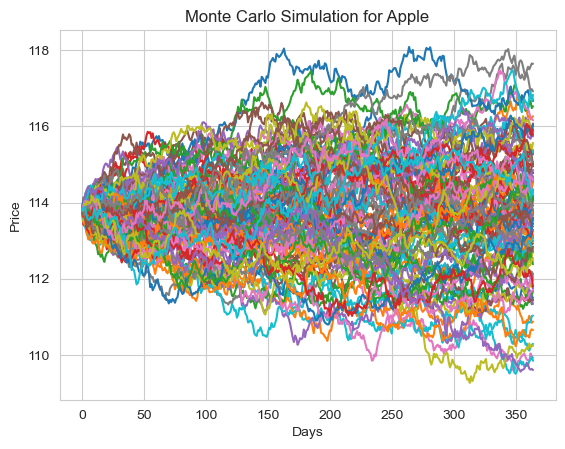

In [16]:
# Running the Monte Carlo simulation a hundred times

start_price = 113.790001

for run in range(100):
    plt.plot(stock_monte_carlo(start_price,days,mu,sigma))
    
plt.xlabel('Days')
plt.ylabel('Price')
plt.title('Monte Carlo Simulation for Apple')

In [17]:
# Analysing the Monte Carlo Simulation for 10,000 simulations

runs = 10000

simulations = np.zeros(runs)

for run in range(runs):
    simulations[run] = stock_monte_carlo(start_price,days,mu,sigma)[days-1]
    
# 1 percent impirical quantile or 99% Confidence Interval

q = np.percentile(simulations,1)

In [ ]:
# Plotting the final Risk Analysis plot using Monte Carlo Simulation

plt.hist(simulations,bins=200)

plt.figtext(0.6, 0.8, s="Start price: $%.2f" %start_price)
# Mean ending price
plt.figtext(0.6, 0.7, "Mean final price: $%.2f" % simulations.mean())

# Variance of the price (within 99% confidence interval)
plt.figtext(0.6, 0.6, "VaR(0.99): $%.2f" % (start_price - q,))

# Display 1% quantile
plt.figtext(0.15, 0.6, "q(0.99): $%.2f" % q)

# Plot a line at the 1% quantile result
plt.axvline(x=q, linewidth=4, color='r')

# Title
plt.title(u"Final price distribution for Apple Stock after %s days" % days, weight='bold');

In [ ]:
# Importing all the essential Python libraries

import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set_style('whitegrid')

import yfinance as yf
from datetime import datetime

# Define the time period
end = datetime.now()
start= datetime(end.year-1,end.month,end.day)

# Fetch the APPLE data using yfinance
AAPL = yf.download("AAPL", start=start, end=end)

AAPL=pd.DataFrame(AAPL)

# Some Basic info about the Apple Stock

AAPL.describe()

# Plotting Adjusted Closing price for Apple Stock

AAPL['Adj Close'].plot(legend=True,figsize=(10,4))

# Plotting the total volume of stock being traded each day

AAPL['Volume'].plot(legend=True,figsize=(10,4))

# Calculating Moving average for 10, 20 and 50 days of the stock price

ma_day = [10, 20, 50]

for ma in ma_day:
    column_name = "MA for %s days" % (str(ma))
    
    AAPL[column_name] = AAPL['Adj Close'].rolling(window=ma).mean()

# Plotting the moving averages

AAPL[['Adj Close', 'MA for 10 days','MA for 20 days','MA for 50 days']].plot(subplots=False,figsize=(10,4))

# Plotting Daily returns as a function of Percent change in Adjusted Close value

AAPL['Daily Return'] = AAPL['Adj Close'].pct_change()

AAPL['Daily Return'].plot(legend=True)

# Plotting the average daily returns of the stock

sns.distplot(AAPL['Daily Return'].dropna(),bins=100)

# Risk Analysis --  Comparing the Risk vs Expected returns

rets = AAPL['Daily Return'].dropna()

area = np.pi*15

plt.scatter(rets.mean(),rets.std(),s=area)

plt.xlabel('Expected Returns')
plt.ylabel('Risk')

# Visualizing the Value at Risk

sns.distplot(AAPL['Daily Return'].dropna(),bins=100)

# Using Quantiles and the Bootstrap Method to calculate the numerical risk of the stock

AAPL['Daily Return'].quantile(0.05)

## Monte Carlo Simulation

days = 365

dt = 1/days

mu = rets.mean()

sigma = rets.std()

# Defining the Monte Carlo Simulation Function

def stock_monte_carlo(start_price,days,mu,sigma):
    
    price = np.zeros(days)
    price[0] = start_price
    
    shock = np.zeros(days)
    drift = np.zeros(days)
    
    for x in range(1,days):
        shock[x] = np.random.normal(loc=mu*dt,scale=sigma*np.sqrt(dt))
        
        drift[x] = mu * dt
        
        price[x] = price[x-1] + (price[x-1]* (drift[x] + shock[x]))
        
    return price

# Running the Monte Carlo simulation a hundred times

start_price = 113.790001

for run in range(100):
    plt.plot(stock_monte_carlo(start_price,days,mu,sigma))
    
plt.xlabel('Days')
plt.ylabel('Price')
plt.title('Monte Carlo Simulation for Apple')

# Analysing the Monte Carlo Simulation for 10,000 simulations

runs = 10000

simulations = np.zeros(runs)

for run in range(runs):
    simulations[run] = stock_monte_carlo(start_price,days,mu,sigma)[days-1]
    
# 1 percent impirical quantile or 99% Confidence Interval

q = np.percentile(simulations,1)

# Plotting the final Risk Analysis plot using Monte Carlo Simulation

plt.hist(simulations,bins=200)

plt.figtext(0.6, 0.8, s="Start price: $%.2f" %start_price)
# Mean ending price
plt.figtext(0.6, 0.7, "Mean final price: $%.2f" % simulations.mean())

# Variance of the price (within 99% confidence interval)
plt.figtext(0.6, 0.6, "VaR(0.99): $%.2f" % (start_price - q,))

# Display 1% quantile
plt.figtext(0.15, 0.6, "q(0.99): $%.2f" % q)

# Plot a line at the 1% quantile result
plt.axvline(x=q, linewidth=4, color='r')

# Title
plt.title(u"Final price distribution for Apple Stock after %s days" % days, weight='bold');